In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv(r"C:\Sales Analysis\data\processed\cleaned_sales_no_outliers.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,IsCancelled,Revenue,Month
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490,United Kingdom,False,257.64,2019-12
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069,United Kingdom,False,383.40,2019-12
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069,United Kingdom,False,138.36,2019-12
3,581475,2019-12-09,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069,United Kingdom,False,127.80,2019-12
4,581475,2019-12-09,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069,United Kingdom,False,71.64,2019-12


In [2]:
snapshot_date = df['Date'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

Snapshot date: 2019-12-10 00:00:00


In [3]:
rfm = df.groupby('CustomerNo').agg(
    Recency=('Date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('TransactionNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm.head()

,CustomerNo,Recency,Frequency,Monetary
0,12004,228,1,1509.60
1,12006,219,1,24.76
2,12008,277,1,5689.57
3,12013,360,1,69.96
4,12024,177,1,149.52


In [4]:
print(rfm.shape)
rfm[['Recency', 'Frequency', 'Monetary']].describe()

(4717, 4)


,Recency,Frequency,Monetary
count,4717.000000,4717.000000,4.717000e+03
mean,96.987704,4.194827,1.295804e+04
std,101.717189,7.396816,5.105960e+04
min,1.000000,1.000000,5.970000e+00
25%,19.000000,1.000000,1.834580e+03
50%,54.000000,2.000000,4.817560e+03
75%,157.000000,5.000000,1.189055e+04
max,374.000000,207.000000,2.112282e+06


In [5]:
print(rfm.sort_values('Monetary', ascending=False).head(10))

      CustomerNo  Recency  Frequency    Monetary
1879       14646        2         73  2112282.03
2084       14911        2        198   914633.52
125        12415       25         20   900545.54
4580       18102        1         60   897137.36
4081       17450        9         46   891438.53
1505       14156       10         54   694965.02
1139       13694        4         51   646116.78
4126       17511        3         31   639006.19
1616       14298        9         44   636167.17
3485       16684        5         28   528587.34


In [6]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

rfm.head(10)

,CustomerNo,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12004,228,1,1509.60,1,1,2,112
1,12006,219,1,24.76,1,1,1,111
2,12008,277,1,5689.57,1,1,3,113
3,12013,360,1,69.96,1,1,1,111
4,12024,177,1,149.52,2,1,1,211
5,12025,288,1,1021.59,1,1,1,111
6,12026,340,1,20486.32,1,1,5,115
7,12031,71,1,136.18,3,1,1,311
8,12042,265,1,6296.77,1,1,3,113
9,12043,158,1,1235.59,2,1,1,211


In [7]:
def segment_customer(row):
    r, f, m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm.head(10)

,CustomerNo,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12004,228,1,1509.60,1,1,2,112,Lost
1,12006,219,1,24.76,1,1,1,111,Lost
2,12008,277,1,5689.57,1,1,3,113,Needs Attention
3,12013,360,1,69.96,1,1,1,111,Lost
4,12024,177,1,149.52,2,1,1,211,Lost
5,12025,288,1,1021.59,1,1,1,111,Lost
6,12026,340,1,20486.32,1,1,5,115,Needs Attention
7,12031,71,1,136.18,3,1,1,311,Needs Attention
8,12042,265,1,6296.77,1,1,3,113,Needs Attention
9,12043,158,1,1235.59,2,1,1,211,Lost


In [8]:
segment_summary = rfm.groupby('Segment').agg(
    Customers=('CustomerNo', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')
).sort_values('TotalRevenue', ascending=False)

segment_summary['PctOfCustomers'] = (segment_summary['Customers'] / segment_summary['Customers'].sum() * 100).round(1)
segment_summary['PctOfRevenue'] = (segment_summary['TotalRevenue'] / segment_summary['TotalRevenue'].sum() * 100).round(1)

print(segment_summary)

                 Customers  AvgRecency  AvgFrequency   AvgMonetary  \
Segment                                                              
Champions              994   13.860161     11.016097  38714.649105   
Loyal Customers       1148   35.699477      3.771777   8861.043798   
At Risk                688  157.069767      3.357558   8469.852384   
Needs Attention        669  124.934230      1.206278   5907.205531   
New Customers          342   19.339181      1.295322   4587.938655   
Lost                   876  233.415525      1.081050   1278.501130   

                 TotalRevenue  PctOfCustomers  PctOfRevenue  
Segment                                                      
Champions         38482361.21            21.1          63.0  
Loyal Customers   10172478.28            24.3          16.6  
At Risk            5827258.44            14.6           9.5  
Needs Attention    3951920.50            14.2           6.5  
New Customers      1569075.02             7.3           2.6  
Lost 

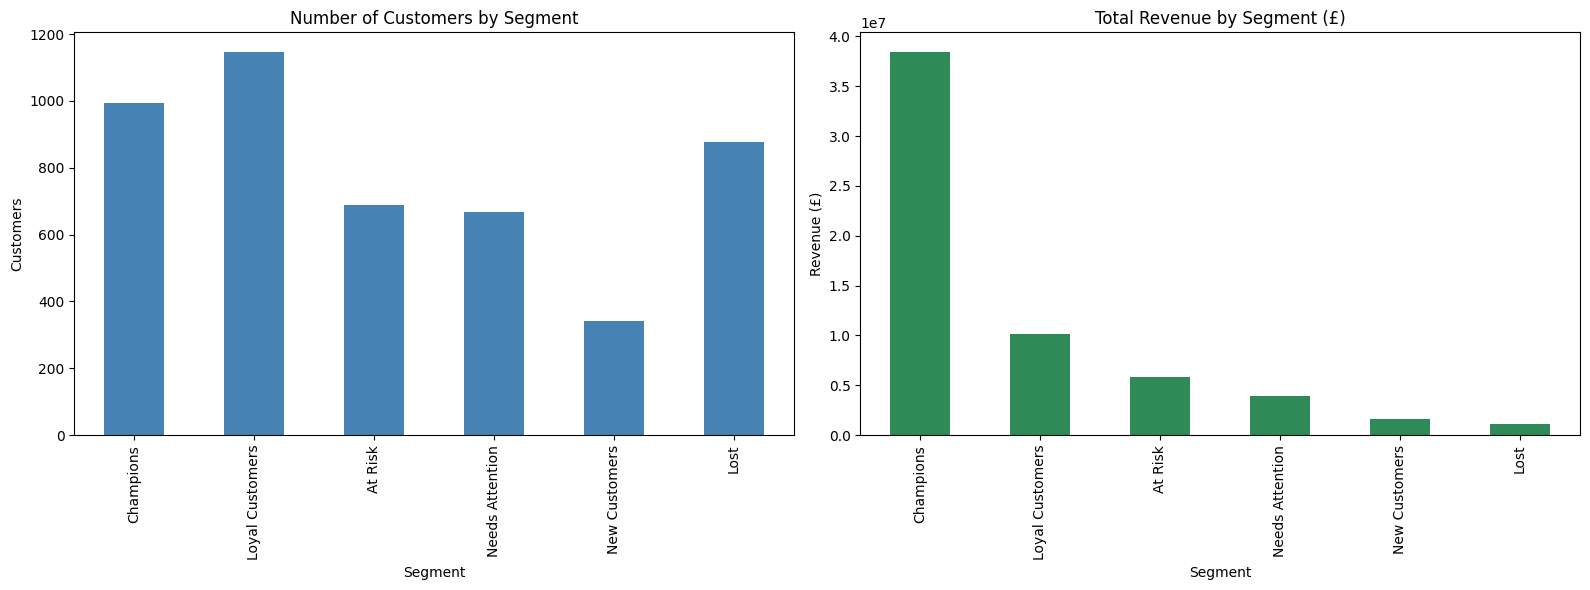

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

segment_summary['Customers'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Number of Customers by Segment')
axes[0].set_ylabel('Customers')

segment_summary['TotalRevenue'].plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Total Revenue by Segment (£)')
axes[1].set_ylabel('Revenue (£)')

plt.tight_layout()
plt.savefig(r"C:\Sales Analysis\output\figures\rfm_segment_summary.png", dpi=300)
plt.show()

In [15]:
rfm.to_csv(r'C:\Sales Analysis\data\processed\rfm_data.csv', index=False)
segment_summary.to_csv(r'C:\Sales Analysis\output\tables\rfm_segment_summary.csv')
print("Saved RFM outputs")

Saved RFM outputs
